# Experiment 02: Outfit Compatibility Classification Baseline

본 실험은 AVA 기반 일반 이미지 미감 분류 baseline 이후,
착장 조화 평가 문제로 연구 대상을 구체화하기 위한 두 번째 실험이다.

Polyvore outfit 데이터를 사용하여 여러 패션 아이템으로 구성된 조합이
compatible한지 incompatible한지를 이진 분류하는 baseline을 구성한다.

본 실험의 목적은 최고 성능 달성이 아니라,
착장 조화 평가 문제를 데이터셋과 모델 구조로 정의할 수 있는지 확인하는 것이다.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/aesthetic-ai"
DATA_DIR = f"{BASE_DIR}/data"
CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
RESULT_DIR = f"{BASE_DIR}/results"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Hugging Face 버전이 Colab에서 로딩 가능한지 확인

In [2]:
!pip install datasets -q

In [4]:
from datasets import load_dataset

dataset = load_dataset("Marqo/polyvore")
dataset

README.md: 0.00B [00:00, ?B/s]

data/data-00000-of-00006.parquet:   0%|          | 0.00/428M [00:00<?, ?B/s]

data/data-00001-of-00006.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

data/data-00002-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00003-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00004-of-00006.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

data/data-00005-of-00006.parquet:   0%|          | 0.00/409M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/94096 [00:00<?, ? examples/s]

DatasetDict({
    data: Dataset({
        features: ['image', 'category', 'text', 'item_ID'],
        num_rows: 94096
    })
})

In [5]:
dataset.keys()

dict_keys(['data'])

In [8]:
# split 이름 확인
print(dataset.keys())

# 전체 구조 확인
print(dataset)

# 첫 번째 샘플 확인
sample = dataset['data'][0]
sample

dict_keys(['data'])
DatasetDict({
    data: Dataset({
        features: ['image', 'category', 'text', 'item_ID'],
        num_rows: 94096
    })
})


{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x400>,
 'category': 'Day Dresses',
 'text': 'tibi knit long sleeve dress',
 'item_ID': '100002074_1'}

Polyvore compatibility 라벨 저장 경로 생성

In [9]:
import os

BASE_DIR = "/content/drive/MyDrive/aesthetic-ai"
DATA_DIR = f"{BASE_DIR}/data"

POLYVORE_DIR = f"{DATA_DIR}/polyvore_xthan"

os.makedirs(POLYVORE_DIR, exist_ok=True)

print("POLYVORE_DIR:", POLYVORE_DIR)

POLYVORE_DIR: /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan


In [10]:
%cd /content/drive/MyDrive/aesthetic-ai/data

!git clone https://github.com/xthan/polyvore-dataset.git polyvore_xthan

/content/drive/MyDrive/aesthetic-ai/data
Cloning into 'polyvore_xthan'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 57 (delta 6), reused 2 (delta 0), pack-reused 45 (from 1)
Receiving objects: 100% (57/57), 8.03 MiB | 14.58 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [11]:
%cd /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan

!ls

/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan
category_id.txt  LICENSE  polyvore.tar.gz  README.md


In [12]:
import os

root = "/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan"

for current_root, dirs, files in os.walk(root):
    depth = current_root.replace(root, "").count(os.sep)
    if depth > 2:
        continue

    indent = "  " * depth
    print(f"{indent}{os.path.basename(current_root)}/")

    for f in files[:10]:
        print(f"{indent}  {f}")

polyvore_xthan/
  LICENSE
  README.md
  category_id.txt
  polyvore.tar.gz
  .git/
    description
    config
    packed-refs
    HEAD
    index
    branches/
    hooks/
      pre-rebase.sample
      commit-msg.sample
      pre-commit.sample
      fsmonitor-watchman.sample
      pre-applypatch.sample
      push-to-checkout.sample
      prepare-commit-msg.sample
      pre-receive.sample
      pre-push.sample
      pre-merge-commit.sample
    info/
      exclude
    refs/
    objects/
    logs/
      HEAD


Polyvore 압축 데이터 파일 확인

In [13]:
%cd /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan

!ls -lh

/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan
total 8.1M
-rw------- 1 root root 6.3K May 19 16:54 category_id.txt
-rw------- 1 root root  12K May 19 16:54 LICENSE
-rw------- 1 root root 8.1M May 19 16:54 polyvore.tar.gz
-rw------- 1 root root 5.7K May 19 16:54 README.md


In [14]:
%cd /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan

!tar -xvzf polyvore.tar.gz

/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan
train_no_dup.json
fill_in_blank_test.json
test_no_dup.json
valid_no_dup.json
fashion_compatibility_prediction.txt


In [15]:
import os

root = "/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan"

for current_root, dirs, files in os.walk(root):
    depth = current_root.replace(root, "").count(os.sep)
    if depth > 3:
        continue

    indent = "  " * depth
    print(f"{indent}{os.path.basename(current_root)}/")

    for f in files[:15]:
        print(f"{indent}  {f}")

polyvore_xthan/
  LICENSE
  README.md
  category_id.txt
  polyvore.tar.gz
  train_no_dup.json
  fill_in_blank_test.json
  test_no_dup.json
  valid_no_dup.json
  fashion_compatibility_prediction.txt
  .git/
    description
    config
    packed-refs
    HEAD
    index
    branches/
    hooks/
      pre-rebase.sample
      commit-msg.sample
      pre-commit.sample
      fsmonitor-watchman.sample
      pre-applypatch.sample
      push-to-checkout.sample
      prepare-commit-msg.sample
      pre-receive.sample
      pre-push.sample
      pre-merge-commit.sample
      applypatch-msg.sample
      post-update.sample
      update.sample
    info/
      exclude
    refs/
      heads/
        master
      tags/
      remotes/
    objects/
      pack/
        pack-b99a4f89ad4c27bf62bec5d15f306210a48ea78b.pack
        pack-b99a4f89ad4c27bf62bec5d15f306210a48ea78b.idx
      info/
    logs/
      HEAD
      refs/


Polyvore 압축 해제 및 compatibility 파일 확인

In [16]:
import json
import os

root = "/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan"

train_json_path = os.path.join(root, "train_no_dup.json")
valid_json_path = os.path.join(root, "valid_no_dup.json")
test_json_path = os.path.join(root, "test_no_dup.json")

with open(train_json_path, "r") as f:
    train_data = json.load(f)

print(type(train_data))
print(len(train_data))
print(train_data[0])

<class 'list'>
17316
{'name': 'Casual', 'views': 8743, 'items': [{'index': 1, 'name': 'mock neck embroidery suede sweatshirt', 'price': 24.0, 'likes': 10, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109', 'categoryid': 4495}, {'index': 2, 'name': 'luxe double zip hooded jacket', 'price': 150.0, 'likes': 2250, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188778349', 'categoryid': 25}, {'index': 3, 'name': 'citizens humanity high rise rocket hem jean', 'price': 248.0, 'likes': 2437, 'image': 'http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188977857', 'categoryid': 27}, {'index': 4, 'name': 'suede tie short boots', 'price': 37.0, 'likes': 2, 'image': 'http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194942557', 'categoryid': 261}, {'index': 5, 'name': 'cloth travel school backpack', 'price': 22.0, 'likes': 2, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194941874', 'category

In [17]:
sample = train_data[0]

print("keys:", sample.keys())

for key, value in sample.items():
    print("\nKEY:", key)
    print("TYPE:", type(value))
    print("VALUE:", value if isinstance(value, (str, int, float)) else str(value)[:500])

keys: dict_keys(['name', 'views', 'items', 'image', 'likes', 'date', 'set_url', 'set_id', 'desc'])

KEY: name
TYPE: <class 'str'>
VALUE: Casual

KEY: views
TYPE: <class 'int'>
VALUE: 8743

KEY: items
TYPE: <class 'list'>
VALUE: [{'index': 1, 'name': 'mock neck embroidery suede sweatshirt', 'price': 24.0, 'likes': 10, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109', 'categoryid': 4495}, {'index': 2, 'name': 'luxe double zip hooded jacket', 'price': 150.0, 'likes': 2250, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188778349', 'categoryid': 25}, {'index': 3, 'name': 'citizens humanity high rise rocket hem jean', 'price': 248.0, 'likes': 2437, 'image': 'http://

KEY: image
TYPE: <class 'str'>
VALUE: http://ak1.polyvoreimg.com/cgi/img-set/cid/214181831/id/El8a99fQ5hG4HrPFO4xqOQ/size/y.jpg

KEY: likes
TYPE: <class 'int'>
VALUE: 394

KEY: date
TYPE: <class 'str'>
VALUE: One month

KEY: set_url
TYPE: <class 'str'>
VALUE: http://www

In [18]:
compat_path = os.path.join(root, "fashion_compatibility_prediction.txt")

with open(compat_path, "r") as f:
    for i in range(20):
        print(f.readline().strip())

1 119704139_1 119704139_2 119704139_3 119704139_4 119704139_5
1 119314458_1 119314458_2 119314458_3 119314458_4 119314458_5 119314458_6 119314458_7 119314458_8
1 147361785_1 147361785_2 147361785_3 147361785_4 147361785_5 147361785_6
1 148015877_1 148015877_2 148015877_3 148015877_4
1 192637078_1 192637078_2 192637078_3 192637078_4 192637078_5 192637078_6 192637078_7 192637078_8
1 163560873_1 163560873_2 163560873_3 163560873_4 163560873_5 163560873_6
1 136727316_1 136727316_2 136727316_3 136727316_4 136727316_5 136727316_6
1 208454316_1 208454316_2 208454316_3 208454316_4 208454316_5 208454316_6 208454316_7
1 206598043_1 206598043_2 206598043_3 206598043_4
1 134837971_1 134837971_2 134837971_3 134837971_4
1 206741058_1 206741058_2 206741058_3 206741058_4 206741058_5 206741058_6 206741058_7
1 204924043_1 204924043_2 204924043_3 204924043_5 204924043_6
1 100111991_1 100111991_2 100111991_3 100111991_4 100111991_5 100111991_6 100111991_7 100111991_8
1 112157720_1 112157720_2 112157720_3 

In [19]:
def count_lines(path):
    with open(path, "r") as f:
        return sum(1 for _ in f)

print("train_no_dup:", len(train_data))

with open(valid_json_path, "r") as f:
    valid_data = json.load(f)

with open(test_json_path, "r") as f:
    test_data = json.load(f)

print("valid_no_dup:", len(valid_data))
print("test_no_dup:", len(test_data))
print("fashion_compatibility_prediction lines:", count_lines(compat_path))

train_no_dup: 17316
valid_no_dup: 1497
test_no_dup: 3076
fashion_compatibility_prediction lines: 7076


In [20]:
image_exts = [".jpg", ".jpeg", ".png"]

image_files = []

for current_root, dirs, files in os.walk(root):
    for f in files:
        if any(f.lower().endswith(ext) for ext in image_exts):
            image_files.append(os.path.join(current_root, f))

print("image file count:", len(image_files))
print(image_files[:10])

image file count: 0
[]


이미지 URL 테스트

In [21]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# train_data가 이미 로드되어 있다고 가정
sample_outfit = train_data[0]
sample_item = sample_outfit["items"][0]

url = sample_item["image"]
print("image url:", url)

response = requests.get(url, timeout=10)
print("status code:", response.status_code)
print("content type:", response.headers.get("Content-Type"))

img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

image url: http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109
status code: 200
content type: text/html; charset=utf-8


UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7dfac971ecf0>

Marqo 데이터와 xthan 라벨 매칭 확인

In [22]:
# Marqo/polyvore의 item_ID 목록 확인
marqo_data = dataset["data"]

marqo_item_ids = set(marqo_data["item_ID"])

print("Marqo item count:", len(marqo_item_ids))

# 샘플 확인
for i, item_id in enumerate(list(marqo_item_ids)[:10]):
    print(item_id)

Marqo item count: 94096
216656592_5
214062402_6
190839664_1
205571989_2
200570446_4
168898746_6
130740470_5
204348256_7
119709182_7
169673416_4


In [23]:
import os

root = "/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan"
compat_path = os.path.join(root, "fashion_compatibility_prediction.txt")

xthan_item_keys = set()
compat_samples = []

with open(compat_path, "r") as f:
    for line in f:
        parts = line.strip().split()

        if len(parts) < 2:
            continue

        label = int(parts[0])
        item_keys = parts[1:]

        compat_samples.append({
            "label": label,
            "item_keys": item_keys
        })

        xthan_item_keys.update(item_keys)

print("compat sample count:", len(compat_samples))
print("xthan unique item keys:", len(xthan_item_keys))

for i, item_key in enumerate(list(xthan_item_keys)[:10]):
    print(item_key)

compat sample count: 7076
xthan unique item keys: 18604
197552878_2
213944371_1
216656592_5
216854564_4
216316318_6
157478799_1
103152950_4
200196164_2
207366484_1
212815077_4


In [24]:
matched_item_keys = xthan_item_keys.intersection(marqo_item_ids)

print("xthan unique item keys:", len(xthan_item_keys))
print("matched item keys:", len(matched_item_keys))
print("match ratio:", len(matched_item_keys) / len(xthan_item_keys))

print("matched sample:", list(matched_item_keys)[:10])

xthan unique item keys: 18604
matched item keys: 15285
match ratio: 0.821597505912707
matched sample: ['197552878_2', '216854564_4', '216656592_5', '216316318_6', '157478799_1', '103152950_4', '200196164_2', '207366484_1', '212815077_4', '210010245_6']


In [25]:
valid_samples = []
invalid_samples = []

for sample in compat_samples:
    item_keys = sample["item_keys"]

    if all(key in marqo_item_ids for key in item_keys):
        valid_samples.append(sample)
    else:
        invalid_samples.append(sample)

print("total compat samples:", len(compat_samples))
print("valid samples:", len(valid_samples))
print("invalid samples:", len(invalid_samples))
print("valid sample ratio:", len(valid_samples) / len(compat_samples))

print("valid sample example:", valid_samples[0] if valid_samples else None)

total compat samples: 7076
valid samples: 2420
invalid samples: 4656
valid sample ratio: 0.34200113058224985
valid sample example: {'label': 1, 'item_keys': ['147361785_1', '147361785_2', '147361785_3', '147361785_4', '147361785_5', '147361785_6']}


valid_samples 라벨 분포 확인

In [26]:
from collections import Counter

valid_label_counts = Counter([sample["label"] for sample in valid_samples])

print("valid label counts:", valid_label_counts)

total_valid = len(valid_samples)
for label, count in valid_label_counts.items():
    print(f"label {label}: {count} ({count / total_valid:.4f})")

valid label counts: Counter({0: 1281, 1: 1139})
label 1: 1139 (0.4707)
label 0: 1281 (0.5293)


Marqo item_ID → dataset index 매핑 생성

In [27]:
# Marqo item_ID -> dataset index 매핑 생성

marqo_data = dataset["data"]

item_id_to_index = {}

for idx, item_id in enumerate(marqo_data["item_ID"]):
    item_id_to_index[item_id] = idx

print("item_id_to_index size:", len(item_id_to_index))

# valid sample 첫 번째 item들이 실제로 찾아지는지 확인
sample = valid_samples[0]
print("sample label:", sample["label"])
print("sample item keys:", sample["item_keys"])

for key in sample["item_keys"]:
    print(key, "->", item_id_to_index.get(key))

item_id_to_index size: 94096
sample label: 1
sample item keys: ['147361785_1', '147361785_2', '147361785_3', '147361785_4', '147361785_5', '147361785_6']
147361785_1 -> 18047
147361785_2 -> 18048
147361785_3 -> 18049
147361785_4 -> 18050
147361785_5 -> 18051
147361785_6 -> 18052


label: 1
image count: 6


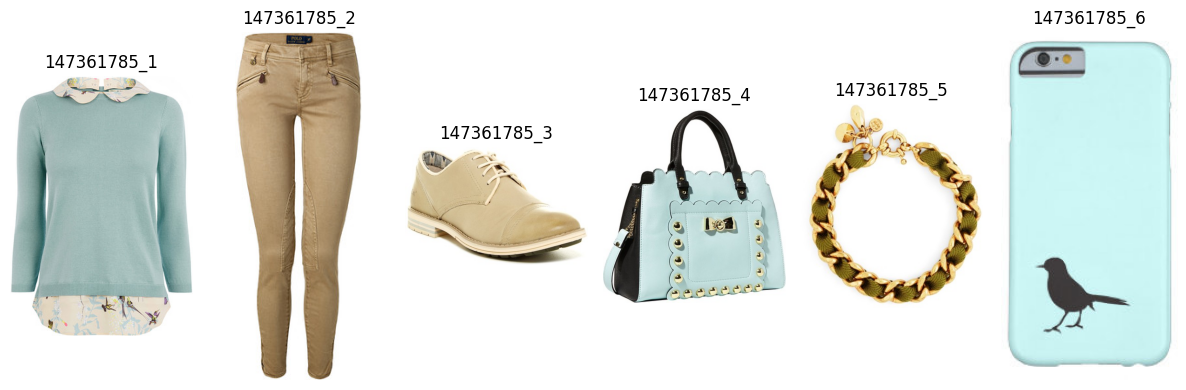

In [28]:
import matplotlib.pyplot as plt

sample = valid_samples[0]

images = []

for key in sample["item_keys"]:
    idx = item_id_to_index[key]
    img = marqo_data[idx]["image"]
    images.append(img)

print("label:", sample["label"])
print("image count:", len(images))

plt.figure(figsize=(12, 4))

for i, img in enumerate(images[:6]):
    plt.subplot(1, 6, i + 1)
    plt.imshow(img)
    plt.title(sample["item_keys"][i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
from PIL import Image

def resize_with_padding(img, size=(224, 224)):
    img = img.convert("RGB")
    img.thumbnail(size)

    canvas = Image.new("RGB", size, (255, 255, 255))

    left = (size[0] - img.width) // 2
    top = (size[1] - img.height) // 2

    canvas.paste(img, (left, top))
    return canvas


def build_outfit_grid(images, cell_size=(224, 224), grid_size=(3, 3)):
    max_items = grid_size[0] * grid_size[1]

    processed = []

    for img in images[:max_items]:
        processed.append(resize_with_padding(img, cell_size))

    while len(processed) < max_items:
        processed.append(Image.new("RGB", cell_size, (255, 255, 255)))

    grid_width = cell_size[0] * grid_size[1]
    grid_height = cell_size[1] * grid_size[0]

    grid = Image.new("RGB", (grid_width, grid_height), (255, 255, 255))

    for idx, img in enumerate(processed):
        row = idx // grid_size[1]
        col = idx % grid_size[1]

        x = col * cell_size[0]
        y = row * cell_size[1]

        grid.paste(img, (x, y))

    return grid

grid image size: (672, 672)
label: 1


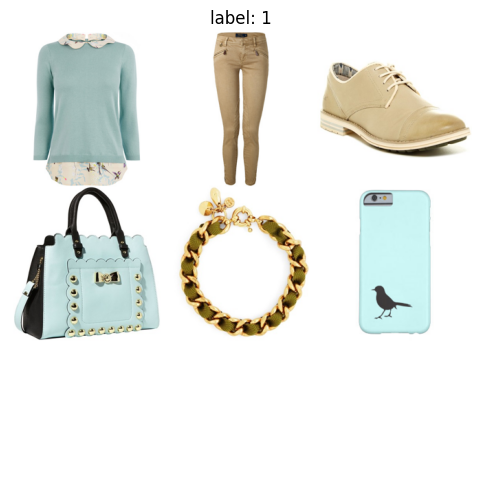

In [30]:
grid_img = build_outfit_grid(images, cell_size=(224, 224), grid_size=(3, 3))

print("grid image size:", grid_img.size)
print("label:", sample["label"])

plt.figure(figsize=(6, 6))
plt.imshow(grid_img)
plt.title(f"label: {sample['label']}")
plt.axis("off")
plt.show()

전체 grid 이미지 저장 + labels.csv 생성

In [31]:
import os

EXP02_DIR = "/content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids"
GRID_IMAGE_DIR = os.path.join(EXP02_DIR, "images")

os.makedirs(GRID_IMAGE_DIR, exist_ok=True)

print("EXP02_DIR:", EXP02_DIR)
print("GRID_IMAGE_DIR:", GRID_IMAGE_DIR)

EXP02_DIR: /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids
GRID_IMAGE_DIR: /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/images


In [32]:
import pandas as pd
from tqdm import tqdm

records = []

for sample_idx, sample in enumerate(tqdm(valid_samples)):
    label = sample["label"]
    item_keys = sample["item_keys"]

    images = []

    for key in item_keys:
        idx = item_id_to_index[key]
        img = marqo_data[idx]["image"]
        images.append(img)

    grid_img = build_outfit_grid(images, cell_size=(224, 224), grid_size=(3, 3))

    file_name = f"outfit_{sample_idx:06d}.jpg"
    save_path = os.path.join(GRID_IMAGE_DIR, file_name)

    grid_img.save(save_path, quality=95)

    records.append({
        "image_path": save_path,
        "label": label,
        "sample_id": sample_idx,
        "num_items": len(item_keys)
    })

labels_df = pd.DataFrame(records)

labels_csv_path = os.path.join(EXP02_DIR, "labels.csv")
labels_df.to_csv(labels_csv_path, index=False)

print("saved images:", len(records))
print("labels_csv_path:", labels_csv_path)
labels_df.head()

100%|██████████| 2420/2420 [01:23<00:00, 29.05it/s]


saved images: 2420
labels_csv_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels.csv


,image_path,label,sample_id,num_items
0,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,0,6
1,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,1,4
2,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,2,6
3,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,3,4
4,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,4,8


In [33]:
import pandas as pd
from collections import Counter

labels_df = pd.read_csv(labels_csv_path)

print(labels_df.shape)
print(labels_df.head())
print(Counter(labels_df["label"]))

(2420, 4)
                                          image_path  label  sample_id  \
0  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          0   
1  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          1   
2  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          2   
3  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          3   
4  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          4   

   num_items  
0          6  
1          4  
2          6  
3          4  
4          8  
Counter({0: 1281, 1: 1139})


image_path    /content/drive/MyDrive/aesthetic-ai/data/exper...
label                                                         1
sample_id                                                     0
num_items                                                     6
Name: 0, dtype: object


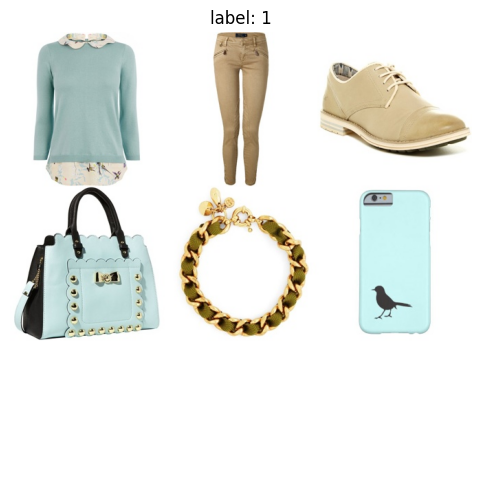

In [34]:
from PIL import Image
import matplotlib.pyplot as plt

sample_row = labels_df.iloc[0]

img = Image.open(sample_row["image_path"]).convert("RGB")

print(sample_row)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"label: {sample_row['label']}")
plt.axis("off")
plt.show()

train / validation split 생성

In [35]:
import pandas as pd
import os

EXP02_DIR = "/content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids"
labels_csv_path = os.path.join(EXP02_DIR, "labels.csv")

labels_df = pd.read_csv(labels_csv_path)

print(labels_df.shape)
print(labels_df.head())
print(labels_df["label"].value_counts())

(2420, 4)
                                          image_path  label  sample_id  \
0  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          0   
1  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          1   
2  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          2   
3  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          3   
4  /content/drive/MyDrive/aesthetic-ai/data/exper...      1          4   

   num_items  
0          6  
1          4  
2          6  
3          4  
4          8  
label
0    1281
1    1139
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    random_state=42,
    stratify=labels_df["label"]
)

print("train:", train_df.shape)
print("validation:", val_df.shape)

print("\ntrain label distribution")
print(train_df["label"].value_counts(normalize=True))
print(train_df["label"].value_counts())

print("\nvalidation label distribution")
print(val_df["label"].value_counts(normalize=True))
print(val_df["label"].value_counts())

train: (1936, 4)
validation: (484, 4)

train label distribution
label
0    0.529442
1    0.470558
Name: proportion, dtype: float64
label
0    1025
1     911
Name: count, dtype: int64

validation label distribution
label
0    0.528926
1    0.471074
Name: proportion, dtype: float64
label
0    256
1    228
Name: count, dtype: int64


In [37]:
train_df = train_df.copy()
val_df = val_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"

split_df = pd.concat([train_df, val_df], ignore_index=True)

split_csv_path = os.path.join(EXP02_DIR, "labels_split.csv")
split_df.to_csv(split_csv_path, index=False)

print("saved:", split_csv_path)
print(split_df.shape)
print(split_df["split"].value_counts())
print(pd.crosstab(split_df["split"], split_df["label"]))

saved: /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels_split.csv
(2420, 5)
split
train    1936
val       484
Name: count, dtype: int64
label     0    1
split           
train  1025  911
val     256  228


PyTorch Dataset 구성

In [38]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class OutfitGridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [39]:
from torchvision import transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = OutfitGridDataset(train_df, transform=train_transform)
val_dataset = OutfitGridDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("train dataset:", len(train_dataset))
print("validation dataset:", len(val_dataset))

images, labels = next(iter(train_loader))
print("batch images:", images.shape)
print("batch labels:", labels.shape)
print("labels:", labels[:10])

train dataset: 1936
validation dataset: 484
batch images: torch.Size([16, 3, 224, 224])
batch labels: torch.Size([16])
labels: tensor([0, 1, 1, 0, 0, 1, 0, 0, 1, 0])


ResNet18 baseline 학습

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


cuda 변경 후 그다음 labels_split.csv 바로 로딩

In [4]:
import os
import pandas as pd

EXP02_DIR = "/content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids"
split_csv_path = os.path.join(EXP02_DIR, "labels_split.csv")

split_df = pd.read_csv(split_csv_path)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "val"].reset_index(drop=True)

print("train:", train_df.shape)
print("val:", val_df.shape)
print(pd.crosstab(split_df["split"], split_df["label"]))

train: (1936, 5)
val: (484, 5)
label     0    1
split           
train  1025  911
val     256  228


In [5]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class OutfitGridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
from torchvision import transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = OutfitGridDataset(train_df, transform=train_transform)
val_dataset = OutfitGridDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("train dataset:", len(train_dataset))
print("validation dataset:", len(val_dataset))

images, labels = next(iter(train_loader))
print("batch images:", images.shape)
print("batch labels:", labels.shape)
print("labels:", labels[:10])

train dataset: 1936
validation dataset: 484
batch images: torch.Size([16, 3, 224, 224])
batch labels: torch.Size([16])
labels: tensor([1, 1, 1, 0, 1, 0, 0, 0, 0, 0])


In [7]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

num_epochs = 5

ResNet18 학습 함수 + 5 epoch 학습

In [15]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="val", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

위 너무 오래 걸려서 수정하고 다시 돌리기

In [11]:
import os
import shutil
import pandas as pd

DRIVE_EXP02_DIR = "/content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids"
LOCAL_EXP02_DIR = "/content/experiment_02_polyvore_grids"

# 로컬에 이미지 폴더 복사
if not os.path.exists(LOCAL_EXP02_DIR):
    shutil.copytree(DRIVE_EXP02_DIR, LOCAL_EXP02_DIR)

print("copied to:", LOCAL_EXP02_DIR)

copied to: /content/experiment_02_polyvore_grids


In [12]:
split_csv_path = os.path.join(LOCAL_EXP02_DIR, "labels_split.csv")
split_df = pd.read_csv(split_csv_path)

split_df["image_path"] = split_df["image_path"].str.replace(
    DRIVE_EXP02_DIR,
    LOCAL_EXP02_DIR,
    regex=False
)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "val"].reset_index(drop=True)

print(train_df.iloc[0]["image_path"])
print(os.path.exists(train_df.iloc[0]["image_path"]))

/content/experiment_02_polyvore_grids/images/outfit_000252.jpg
True


In [13]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class OutfitGridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = OutfitGridDataset(train_df, transform=train_transform)
val_dataset = OutfitGridDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("batch images:", images.shape)
print("batch labels:", labels.shape)
print("labels:", labels[:10])

batch images: torch.Size([16, 3, 224, 224])
batch labels: torch.Size([16])
labels: tensor([1, 0, 1, 0, 0, 1, 1, 1, 0, 1])


DataLoader 확인 이후 ResNet18 학습 단계 진행

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print(model.fc)

device: cuda
Linear(in_features=512, out_features=2, bias=True)


In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

num_epochs = 5

In [18]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="val", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [19]:
import os
import torch

CHECKPOINT_DIR = "/content/drive/MyDrive/aesthetic-ai/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

history = []

best_val_acc = 0.0
best_model_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_outfit_compatibility_exp02.pth"
)

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch + 1}/{num_epochs}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels, val_preds = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}")
    print(f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"best model saved: {best_model_path}")

print("\nBest validation accuracy:", best_val_acc)


Epoch [1/5]


train_loss: 0.6431 | train_acc: 0.6410
val_loss: 0.6334 | val_acc: 0.6591
best model saved: /content/drive/MyDrive/aesthetic-ai/checkpoints/resnet18_outfit_compatibility_exp02.pth

Epoch [2/5]


train_loss: 0.3743 | train_acc: 0.8347
val_loss: 0.7287 | val_acc: 0.6508

Epoch [3/5]


train_loss: 0.1986 | train_acc: 0.9210
val_loss: 1.0492 | val_acc: 0.6818
best model saved: /content/drive/MyDrive/aesthetic-ai/checkpoints/resnet18_outfit_compatibility_exp02.pth

Epoch [4/5]


train_loss: 0.1640 | train_acc: 0.9427
val_loss: 1.1763 | val_acc: 0.6736

Epoch [5/5]


train_loss: 0.1437 | train_acc: 0.9427
val_loss: 0.9351 | val_acc: 0.6798

Best validation accuracy: 0.6818181818181818


In [20]:
import pandas as pd
import os

RESULT_DIR = "/content/drive/MyDrive/aesthetic-ai/results"
os.makedirs(RESULT_DIR, exist_ok=True)

history_df = pd.DataFrame(history)

history_path = os.path.join(
    RESULT_DIR,
    "resnet18_outfit_compatibility_history.csv"
)

history_df.to_csv(history_path, index=False)

print("saved:", history_path)
history_df

saved: /content/drive/MyDrive/aesthetic-ai/results/resnet18_outfit_compatibility_history.csv


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.643087,0.641012,0.633351,0.659091
1,2,0.374262,0.834711,0.728747,0.650826
2,3,0.198630,0.920971,1.049173,0.681818
3,4,0.164023,0.942665,1.176320,0.673554
4,5,0.143734,0.942665,0.935138,0.679752


In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import torch

model.load_state_dict(torch.load(best_model_path, map_location=device))

val_loss, val_acc, val_labels, val_preds = validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
)

cm = confusion_matrix(val_labels, val_preds)

print("Validation Accuracy:", val_acc)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["incompatible", "compatible"]
))

Validation Accuracy: 0.6818181818181818
Confusion Matrix:
[[193  63]
 [ 91 137]]

Classification Report:
              precision    recall  f1-score   support

incompatible       0.68      0.75      0.71       256
  compatible       0.69      0.60      0.64       228

    accuracy                           0.68       484
   macro avg       0.68      0.68      0.68       484
weighted avg       0.68      0.68      0.68       484



In [22]:
cm_df = pd.DataFrame(
    cm,
    index=["true_incompatible", "true_compatible"],
    columns=["pred_incompatible", "pred_compatible"]
)

cm_path = os.path.join(
    RESULT_DIR,
    "resnet18_outfit_compatibility_confusion_matrix.csv"
)

cm_df.to_csv(cm_path)

print("saved:", cm_path)
cm_df

saved: /content/drive/MyDrive/aesthetic-ai/results/resnet18_outfit_compatibility_confusion_matrix.csv


,pred_incompatible,pred_compatible
true_incompatible,193,63
true_compatible,91,137
